<a href="https://colab.research.google.com/github/mattsmiths/biol470/blob/main/final_project/FinalProject_Analysis_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Click to copy the class code repository
!git clone https://github.com/mattsmiths/biol470.git

Cloning into 'biol470'...
remote: Enumerating objects: 998, done.
remote: Counting objects: 100% (403/403), done.
remote: Compressing objects: 100% (205/205), done.
remote: Total 998 (delta 285), reused 278 (delta 198), pack-reused 595 (from 3)
Receiving objects: 100% (998/998), 937.15 MiB | 24.17 MiB/s, done.
Resolving deltas: 100% (443/443), done.
Updating files: 100% (391/391), done.


In [2]:
#@title Click to import libraries
import cv2 as cv
import os
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd

In [3]:
data1 = pd.read_csv('/content/biol470/final_project/nicotine_bee_1/assay4_inf_final_bee_0415_exp_01_air_cam1_2026-04-15_18-02-38_key.csv')

In [ ]:
data1.head()

,Unnamed: 0,filepath,x_centroid,y_centroid,x_min,y_min,x_max,y_max,detection_confidence
0,0,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2866.5,2485.0,2499,2134,3234,2836,0.787689
1,1,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2863.5,2488.0,2513,2139,3214,2837,0.778611
2,2,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2863.5,2490.5,2511,2133,3216,2848,0.752090
3,3,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2824.0,2491.5,2478,2131,3170,2852,0.737394
4,4,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2813.5,2491.0,2458,2131,3169,2851,0.725658


In [ ]:
x_store = []
y_store = []

# Pulling out the centroid for each detection event
for ind,ele in enumerate(data1['x_min']):
  x_center = (ele+data1['x_max'][ind])/2
  y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
  x_store.append(x_center)
  y_store.append(y_center)





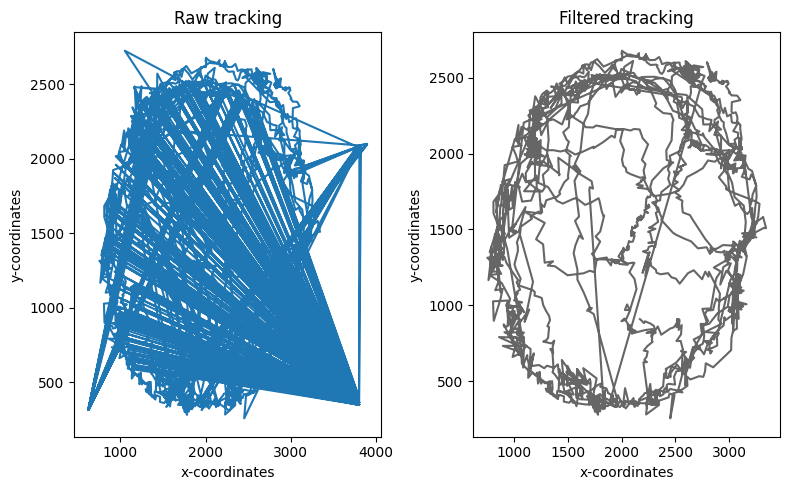

In [ ]:
# Plotting the centroid in x-y space over time
# raw plot
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.title('Raw tracking')
plt.plot(x_store,y_store)
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')

speed = []
x_plot = []
y_plot = []
# updating to euclidean distance
for ind,x1 in enumerate(x_store[1:]):
  previous_pos = np.array([x_store[ind],y_store[ind]])
  current_pos = np.array([x_store[ind+1],y_store[ind+1]])

  # Euclidean distance calculation
  temp = np.linalg.norm((current_pos-previous_pos))

  speed.append(temp)

  # removing noise
  if temp < 250 and x_store[ind+1] < 3500:
    x_plot.append(x_store[ind+1])
    y_plot.append(y_store[ind+1])


plt.subplot(1,2,2)
plt.title('Filtered tracking')
plt.plot(x_plot,y_plot,color=(0.4,0.4,0.4))
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.tight_layout()


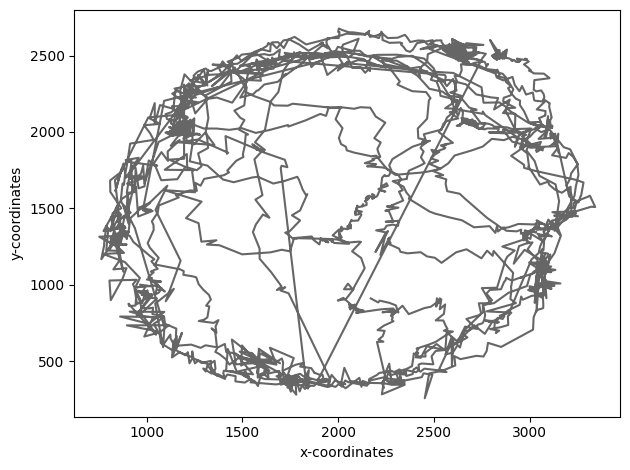

In [ ]:

#plt.title('Filtered tracking')
plt.plot(x_plot,y_plot,color=(0.4,0.4,0.4))
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.tight_layout()
plt.savefig('/content/circle.jpg',dpi=200)

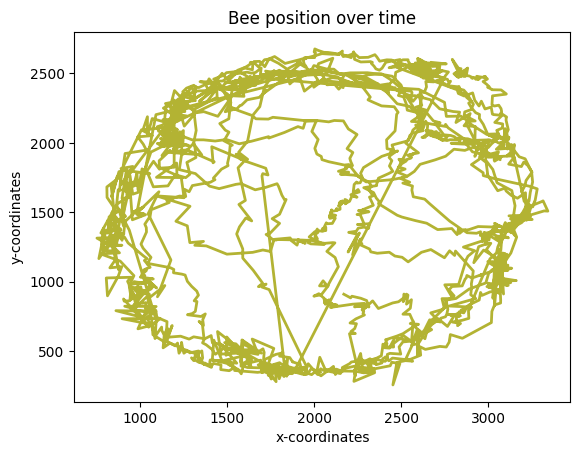

In [ ]:
# Plotting the centroid in x-y space over time
plt.plot(x_plot,y_plot,color=(0.7,0.7,0.2),linewidth=2)
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.title('Bee position over time')
plt.savefig('control_bee2_assay_1.pdf',dpi=200)

In [ ]:
#xdiff = np.diff(x_store)
#ydiff = np.diff(y_store)
#out = abs(xdiff)+abs(ydiff)

speed = []
# updating to euclidean distance
for ind,x1 in enumerate(x_store[1:]):
  previous_pos = np.array([x_store[ind],y_store[ind]])
  current_pos = np.array([x_store[ind+1],y_store[ind+1]])

  # Euclidean distance calculation
  temp = np.linalg.norm((current_pos-previous_pos))

  speed.append(temp)

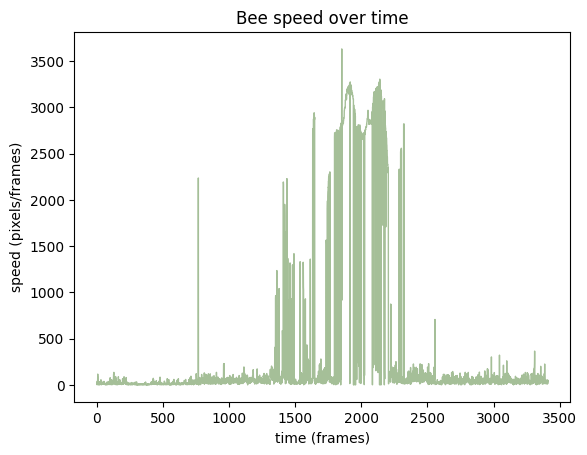

In [ ]:
# Plotting the centroid in x-y space over time
plt.plot(speed,color=(0.3,0.5,0.2,0.5),linewidth=1)
plt.xlabel('time (frames)')
plt.ylabel('speed (pixels/frames)')
plt.title('Bee speed over time')
plt.savefig('control_bee2_assay_1_speed.pdf',dpi=200)

In [ ]:
assayList = ['/content/biol470/final_project/control_bee_2/assay1_inf_bee_0408_2_opto_2026-04-08_16-35-41_arena_circle_1_key.csv',
             '/content/biol470/final_project/control_bee_3/assay1_inf_bee_0408_3_opto_2026-04-08_17-28-06_arena_circle_1_key.csv',
             '/content/biol470/final_project/control_bee_4/assay1_inf_bee_0408_4_opto_2026-04-08_18-08-46_arena_circle_1_key.csv']

allStore_control = []
for bees in assayList:

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)


  allStore_control.append(speed)

In [ ]:
assayList = ['/content/biol470/final_project/nicotine_bee_1/assay1_inf_bee_0415_exp_01_opto_2026-04-15_17-11-24_arena_circle_1_key.csv',
             '/content/biol470/final_project/nicotine_bee_2/assay1_inf_bee_0415_exp_02_opto_2026-04-15_20-58-17_arena_circle_1_key.csv',
             '/content/biol470/final_project/nicotine_bee_3/assay1_inf_bee_0415_exp_03_opto_2026-04-15_22-25-20_arena_circle_1_key.csv']

allStore = []
for bees in assayList:

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

    speed = []
    # updating to euclidean distance
    for ind,x1 in enumerate(x_store[1:]):
      previous_pos = np.array([x_store[ind],y_store[ind]])
      current_pos = np.array([x_store[ind+1],y_store[ind+1]])

      # Euclidean distance calculation
      temp = np.linalg.norm((current_pos-previous_pos))
      speed.append(temp)

  allStore.append(speed)

Text(0, 0.5, 'Avg Speed (pixels/frame)')

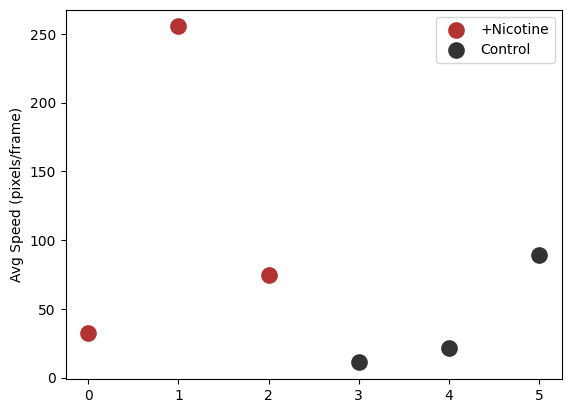

In [ ]:
plt.figure()
for ind,ele in enumerate(allStore):
  if ind == 0:
    plt.scatter(ind,np.nanmean(ele),color=(0.7,0.2,0.2),linewidth=2,s=100,label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(ele),color=(0.7,0.2,0.2),linewidth=2,s=100)

for ind,ele in enumerate(allStore_control):
  if ind == 0:
    plt.scatter(ind+3,np.nanmean(ele),color=(0.2,0.2,0.2),linewidth=2,s=100,label='Control')
  else:
    plt.scatter(ind+3,np.nanmean(ele),color=(0.2,0.2,0.2),linewidth=2,s=100)
plt.legend()

plt.ylabel('Avg Speed (pixels/frame)')



# Arena Circle

In [4]:
findBees = glob.glob('/content/biol470/final_project/*/assay1*')

allStore = {}
for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}

  allStore[bees.split('/')[-2]]['Circle'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Circle'].append(speed)

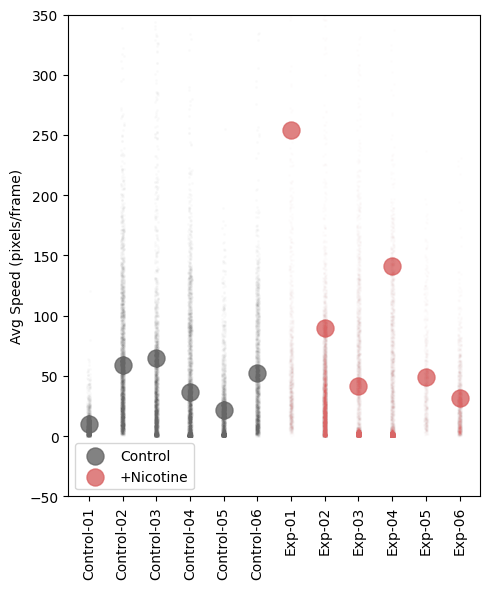

In [5]:
plt.figure(figsize=(5,6))
nbee = {}
nsbee = {}
cbee = {}
csbee = {}

for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    nbee[ele] = np.nanmean(allStore[ele]['Circle'])
    nsbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    cbee[ele] = np.nanmean(allStore[ele]['Circle'])
    csbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))



ind = 0

for ele in cbee:
  if ind == 0:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82),label='Control')
  else:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82))

  #plt.plot([ind,ind],[np.nanmean(cbee[ele])-csbee[ele],np.nanmean(cbee[ele])+csbee[ele]],color=(0.4,0.4,0.4,0.82))

  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.4,0.4,0.4,0.02),s=1)
  ind+=1

for ele in nbee:
  if ind == 6:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82))

  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.85,0.4,0.4,0.01),s=1)
  ind+=1

plt.legend()
plt.xticks(np.arange(0,12),['Control-01','Control-02','Control-03','Control-04','Control-05','Control-06',
                            'Exp-01','Exp-02','Exp-03','Exp-04','Exp-05','Exp-06'],rotation=90)
plt.ylabel('Avg Speed (pixels/frame)')
plt.ylim([-50,350])
plt.tight_layout()
plt.savefig('/content/circle_speed.png',dpi=300)

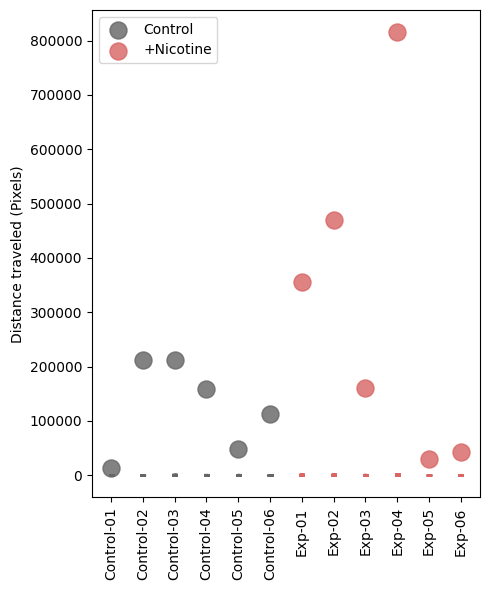

In [6]:
plt.figure(figsize=(5,6))
nbee = {}
nsbee = {}
cbee = {}
csbee = {}

for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    nbee[ele] = np.nansum(allStore[ele]['Circle'])
    nsbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    cbee[ele] = np.nansum(allStore[ele]['Circle'])
    csbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))



ind = 0

bbar = []
for ele in cbee:
  if ind == 0:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82),label='Control')
  else:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82))
  bbar.append(cbee[ele])
  #plt.plot([ind,ind],[np.nanmean(cbee[ele])-csbee[ele],np.nanmean(cbee[ele])+csbee[ele]],color=(0.4,0.4,0.4,0.82))

  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.4,0.4,0.4,0.2),s=1)
  ind+=1

for ele in nbee:
  if ind == 6:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82))
  bbar.append(nbee[ele])
  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.85,0.4,0.4,0.1),s=1)
  ind+=1

plt.legend()
plt.xticks(np.arange(0,12),['Control-01','Control-02','Control-03','Control-04','Control-05','Control-06',
                            'Exp-01','Exp-02','Exp-03','Exp-04','Exp-05','Exp-06'],rotation=90)
plt.ylabel('Distance traveled (Pixels)')
plt.tight_layout()
plt.savefig('/content/circle_dist.png',dpi=300)



/tmp/ipykernel_1997/2981826394.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


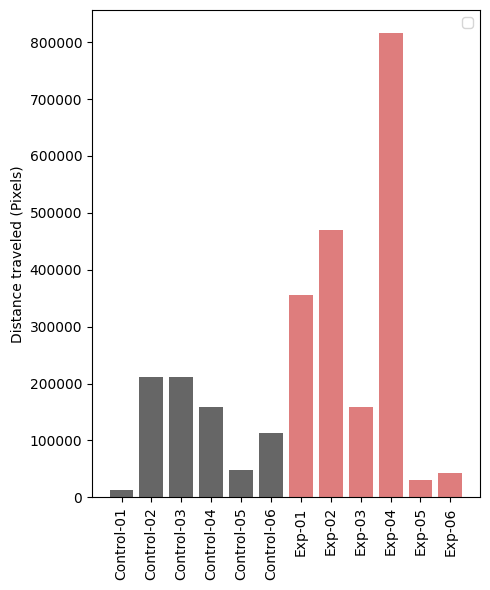

In [7]:
plt.figure(figsize=(5,6))
plt.bar(np.arange(0,6),bbar[:6],color=(0.4,0.4,0.4))
plt.bar(np.arange(6,12),bbar[6:],color=(0.85,0.4,0.4,0.85))
plt.legend()
plt.xticks(np.arange(0,12),['Control-01','Control-02','Control-03','Control-04','Control-05','Control-06',
                            'Exp-01','Exp-02','Exp-03','Exp-04','Exp-05','Exp-06'],rotation=90)
plt.ylabel('Distance traveled (Pixels)')
plt.tight_layout()
a1 = plt.axis()
plt.savefig('/content/circle_dist_bar.png',dpi=300)

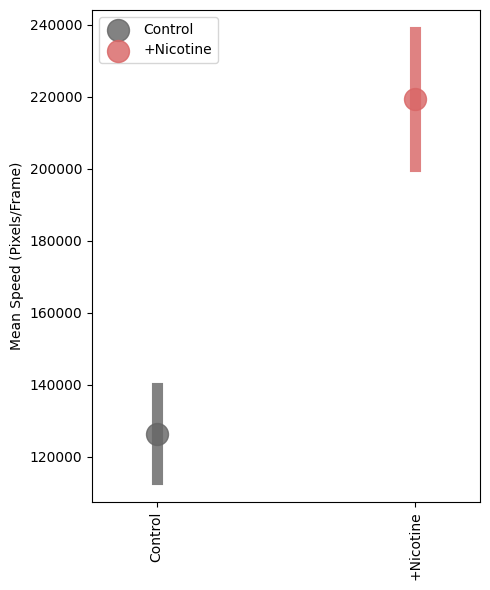

In [8]:
plt.figure(figsize=(5,6))
ff = []

for ele in cbee:
  ff.append(cbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
ind = 0
plt.scatter(ind,control_mean,s=250,color=(0.4,0.4,0.4,0.82),label='Control')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.4,0.4,0.4,0.82),linewidth=8)

ind+=1
for ele in nbee:
  ff.append(nbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
plt.scatter(ind,control_mean,s=250,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.85,0.4,0.4,0.82),linewidth=8)
plt.legend()
plt.ylabel('Mean Speed (Pixels/Frame)')
plt.xticks(np.arange(0,2),['Control','+Nicotine'],rotation=90)
plt.xlim([-0.25,1.25])

plt.tight_layout()
plt.savefig('/content/mean_comp_speed.png',dpi=300)

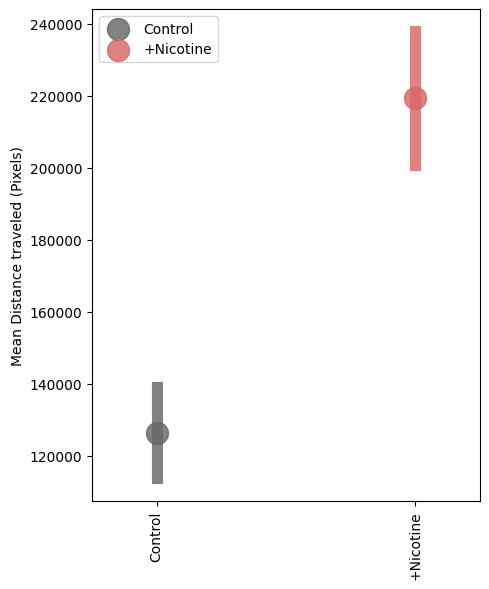

In [9]:
plt.figure(figsize=(5,6))
ff = []

for ele in cbee:
  ff.append(cbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
ind = 0
plt.scatter(ind,control_mean,s=250,color=(0.4,0.4,0.4,0.82),label='Control')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.4,0.4,0.4,0.82),linewidth=8)

ind+=1
for ele in nbee:
  ff.append(nbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
plt.scatter(ind,control_mean,s=250,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.85,0.4,0.4,0.82),linewidth=8)
plt.legend()
plt.ylabel('Mean Distance traveled (Pixels)')
plt.xticks(np.arange(0,2),['Control','+Nicotine'],rotation=90)
plt.xlim([-0.25,1.25])

plt.tight_layout()

plt.tight_layout()
plt.savefig('/content/mean_comp_dist.png',dpi=300)

# Optomotor

In [10]:
import math

In [11]:
findBees = glob.glob('/content/biol470/final_project/*/assay2*fwd*')


for bees in findBees:

  allStore[bees.split('/')[-2]]['Opto_Fwd'] = []
  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []
  rad_store = []
  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  fx = []
  fy = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([2000,1500])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)
    fx.append(x_store[ind+1])
    fy.append(y_store[ind+1])
    #if temp < 500 and x_store[ind+1] > 1000:
    dx = 2000 - x_store[ind]
    dy = 1500 - y_store[ind]
    angle_rad = math.atan2(dy, dx)

    rad_store.append(angle_rad)

  allStore[bees.split('/')[-2]]['Opto_Fwd'].append(np.diff(rad_store))

In [18]:
findBees = glob.glob('/content/biol470/final_project/*/assay2*rev*')


for bees in findBees:

  allStore[bees.split('/')[-2]]['Opto_Rev'] = []
  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []
  rad_store = []
  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  fx = []
  fy = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([2000,1500])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)
    fx.append(x_store[ind+1])
    fy.append(y_store[ind+1])
    #if temp < 500 and x_store[ind+1] > 1000:
    dx = 2000 - x_store[ind]
    dy = 1500 - y_store[ind]
    angle_rad = math.atan2(dy, dx)

    rad_store.append(angle_rad)

  allStore[bees.split('/')[-2]]['Opto_Rev'].append(np.diff(rad_store))

In [19]:
plt.figure()
for ind,ele in enumerate(allStore.keys()):
  if 'Opto' not in allStore[ele]:continue
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  if 'Opto_Fwd' in allStore[ele]:
    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Fwd']),s=150,color=cc1)
  if 'Opto_Rev' in allStore[ele]:
    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Rev']),s=50,color=cc1)

<Figure size 640x480 with 0 Axes>

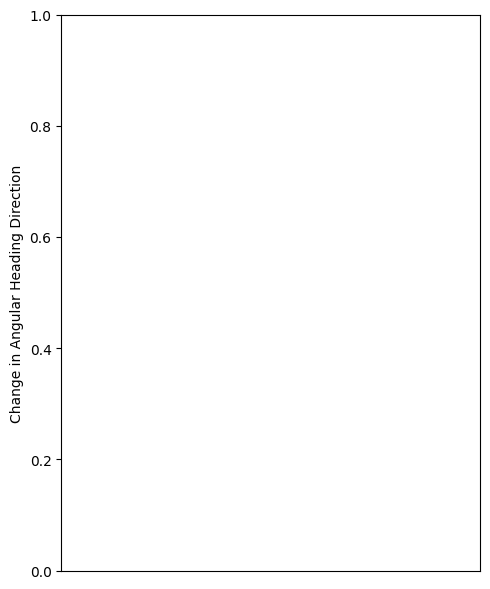

In [20]:
#plt.figure()
plt.figure(figsize=(5,6))
crot = []
nrot = []
for ind,ele in enumerate(allStore.keys()):
  if 'Opto' not in allStore[ele]:continue
  if 'Opto_Fwd' not in allStore[ele] or 'Opto_Rev' not in allStore[ele]:continue
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    crot.append(np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    nrot.append(np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']))

  if 'Opto_Fwd' in allStore[ele] and 'Opto_Rev' in allStore[ele]:


    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Fwd'])-np.nanmean(allStore[ele]['Opto_Fwd']),s=150,color=cc1)
    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']),s=50,color=cc1)
    plt.plot([ind,ind],[np.nanmean(allStore[ele]['Opto_Fwd'])-np.nanmean(allStore[ele]['Opto_Fwd']),np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd'])],color=cc1)


plt.ylabel('Change in Angular Heading Direction')
plt.xticks([])
plt.tight_layout()
plt.savefig('/content/change_opto_ang.png',dpi=300)

In [21]:
plt.figure()
for ind,ele in enumerate(allStore.keys()):
  if 'Opto' not in allStore[ele]:continue
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Opto']),s=100,color=cc1)

<Figure size 640x480 with 0 Axes>

In [22]:
plt.scatter(ind,np.nanmean(allStore[ele]['Opto']),s=100,color=cc1)

KeyError: 'Opto'

/tmp/ipykernel_1997/1453651034.py:5: RuntimeWarning: Mean of empty slice
  control_mean = np.nanmean(crot)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1997/1453651034.py:14: RuntimeWarning: Mean of empty slice
  control_mean = np.nanmean(nrot)


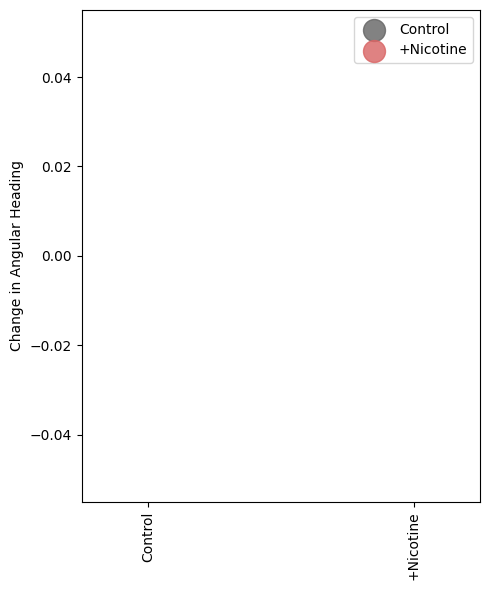

In [23]:
plt.figure(figsize=(5,6))
ff = []


control_mean = np.nanmean(crot)
control_sem = np.nanstd(crot)/len(crot)
ind = 0
plt.scatter(ind,control_mean,s=250,color=(0.4,0.4,0.4,0.82),label='Control')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.4,0.4,0.4,0.82),linewidth=8)

ind+=1
for ele in nbee:
  ff.append(nbee[ele])
control_mean = np.nanmean(nrot)
control_sem = np.nanstd(nrot)/len(nrot)
plt.scatter(ind,control_mean,s=250,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.85,0.4,0.4,0.82),linewidth=8)
plt.legend()
plt.ylabel('Change in Angular Heading')
plt.xticks(np.arange(0,2),['Control','+Nicotine'],rotation=90)
plt.xlim([-0.25,1.25])

plt.tight_layout()

plt.tight_layout()
plt.savefig('/content/change_opto_dist.png',dpi=300)

# Shaded Preference

In [25]:
findBees = glob.glob('/content/biol470/final_project/*/assay3*')

for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}

  allStore[bees.split('/')[-2]]['Shade'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Shade'].append(speed)

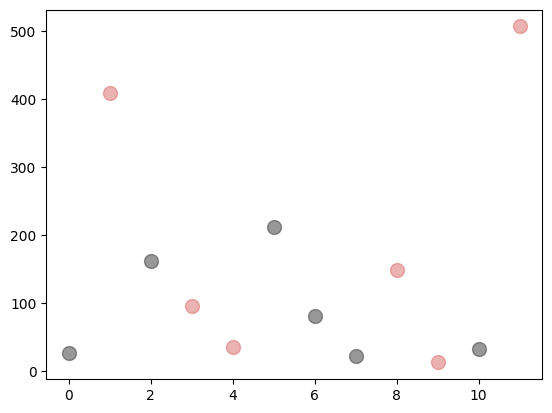

In [26]:
plt.figure()
nbee = {}
cbee = {}

for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    nbee[ele] = np.nanmean(allStore[ele]['Shade'])
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    cbee[ele] = np.nanmean(allStore[ele]['Shade'])



  plt.scatter(ind,np.nanmean(allStore[ele]['Shade']),s=100,color=cc1)

# Air Responses

In [27]:
findBees = glob.glob('/content/biol470/final_project/*/assay4*')

for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}
  allStore[bees.split('/')[-2]]['Air'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  #plt.figure()
  #plt.plot(x_store,y_store)
  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([3200,1500])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Air'].append(speed)


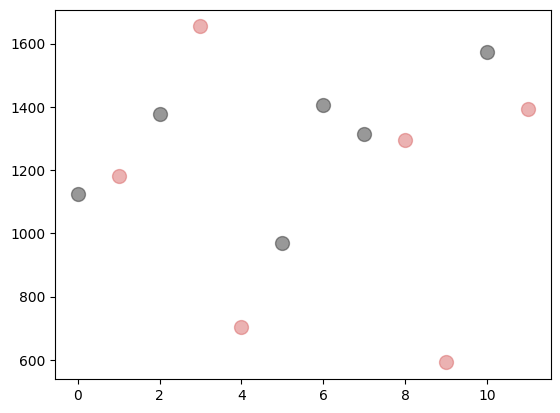

In [28]:
plt.figure()
for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Air']),s=100,color=cc1)

# Citronella Responses

In [29]:
findBees = glob.glob('/content/biol470/final_project/*/assay5*')


for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}
  allStore[bees.split('/')[-2]]['Cit'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([4000,2000])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Cit'].append(speed)


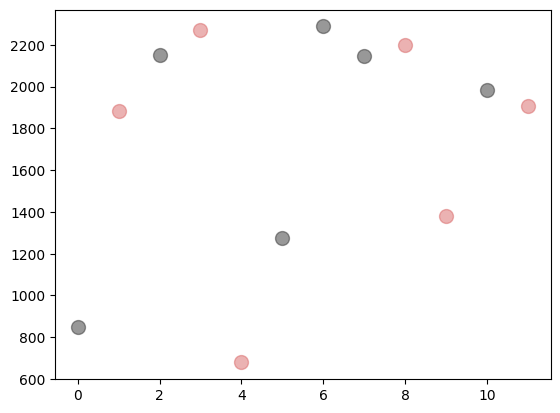

In [30]:
plt.figure()
for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Cit']),s=100,color=cc1)

# Linalool Responses

In [31]:
findBees = glob.glob('/content/biol470/final_project/*/assay6*')

for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}
  allStore[bees.split('/')[-2]]['Lin'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([4000,2000])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Lin'].append(speed)


KeyError: 'Lin'

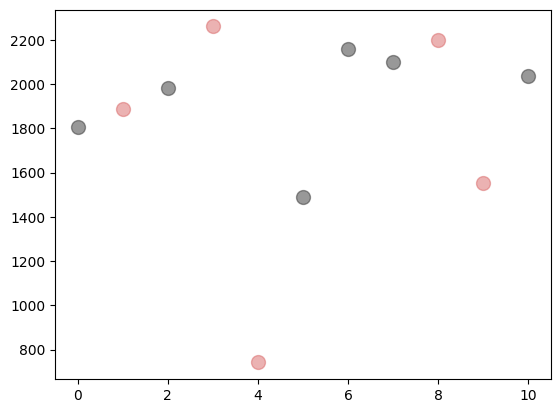

In [32]:
plt.figure()
for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Lin']),s=100,color=cc1)

In [ ]:
!unzip /content/frames.zip

In [ ]:
import cv2 as cv

In [ ]:
in1 = cv.imread('/content/frames/bee_0408_2/final_bee_0408_2_air_cam1_2026-04-08_17-10-27.jpg')

In [ ]:
plt.imshow(in1)

In [ ]:
in1 = cv.imread('/content/frames/bee_0408_3/final_bee_test_cit_cam1_2026-04-08_17-46-11.jpg')

In [ ]:
plt.imshow(in1)

# Matrix

In [33]:
getAll = {}
for ele in allStore:
  for ee in allStore[ele]:
    if ee not in getAll:
      getAll[ee] = []


In [34]:
getAll.keys()

dict_keys(['Circle', 'Shade', 'Air', 'Cit', 'Lin', 'Opto_Fwd', 'Opto_Rev'])

In [35]:
allStore['nicotine_bee_2'].keys()

dict_keys(['Circle', 'Opto_Fwd', 'Shade', 'Air', 'Cit', 'Lin'])

In [36]:
getAll = ['Circle', 'Opto_Fwd', 'Opto_Rev','Shade', 'Air', 'Cit', 'Lin']

In [37]:
nmat = []
cmat = []

nMAT = {}
cMAT = {}
aMAT = {}

for ele in allStore:
  temp = []
  for ee in getAll:
    if ee not in nMAT:
      nMAT[ee] = []
      cMAT[ee] = []
      aMAT[ee] = []

    if ee not in allStore[ele]:
      temp.append(np.nan)
      if 'nic' in ele:
        nMAT[ee].append(np.nan)
      else:
        cMAT[ee].append(np.nan)

      aMAT[ee].append(np.nan)

    else:
      temp.append(np.nanmean(allStore[ele][ee]))

      if 'nic' in ele:
        nMAT[ee].append(np.nanmean(allStore[ele][ee]))
      else:
        cMAT[ee].append(np.nanmean(allStore[ele][ee]))

      aMAT[ee].append(np.nanmean(allStore[ele][ee]))

  if 'nic' in ele:

    nmat.append(temp)
  else:
    cmat.append(temp)


In [ ]:
import pandas as pd
df = pd.DataFrame(aMAT)
matrix = df.corr(numeric_only=True)

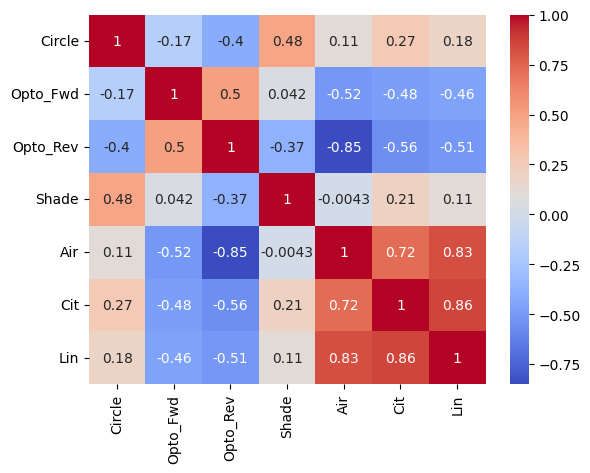

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.show()


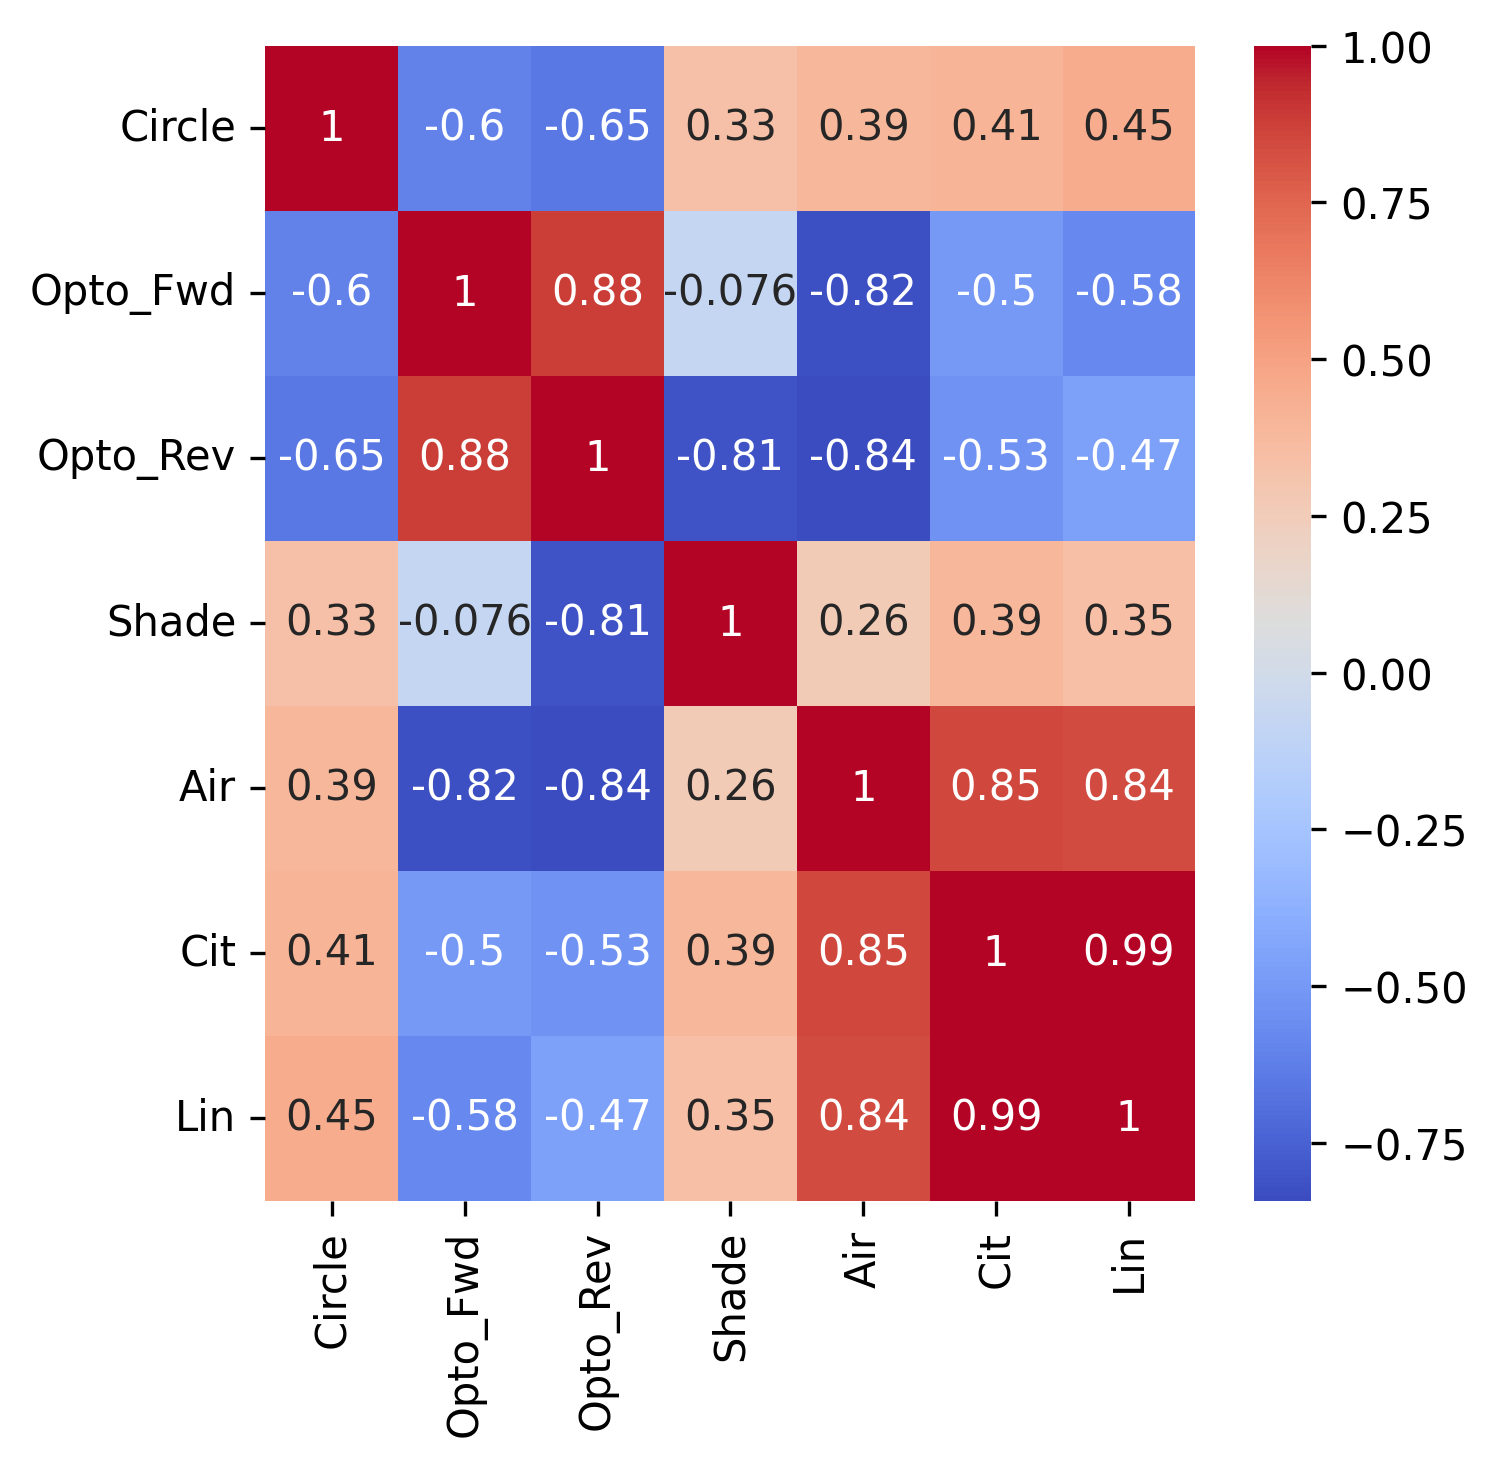

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
df = pd.DataFrame(nMAT)
matrix = df.corr(numeric_only=True)
plt.figure(figsize=(5,5),dpi=300)

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.show()
plt.savefig('/content/nmat.png',dpi=300)

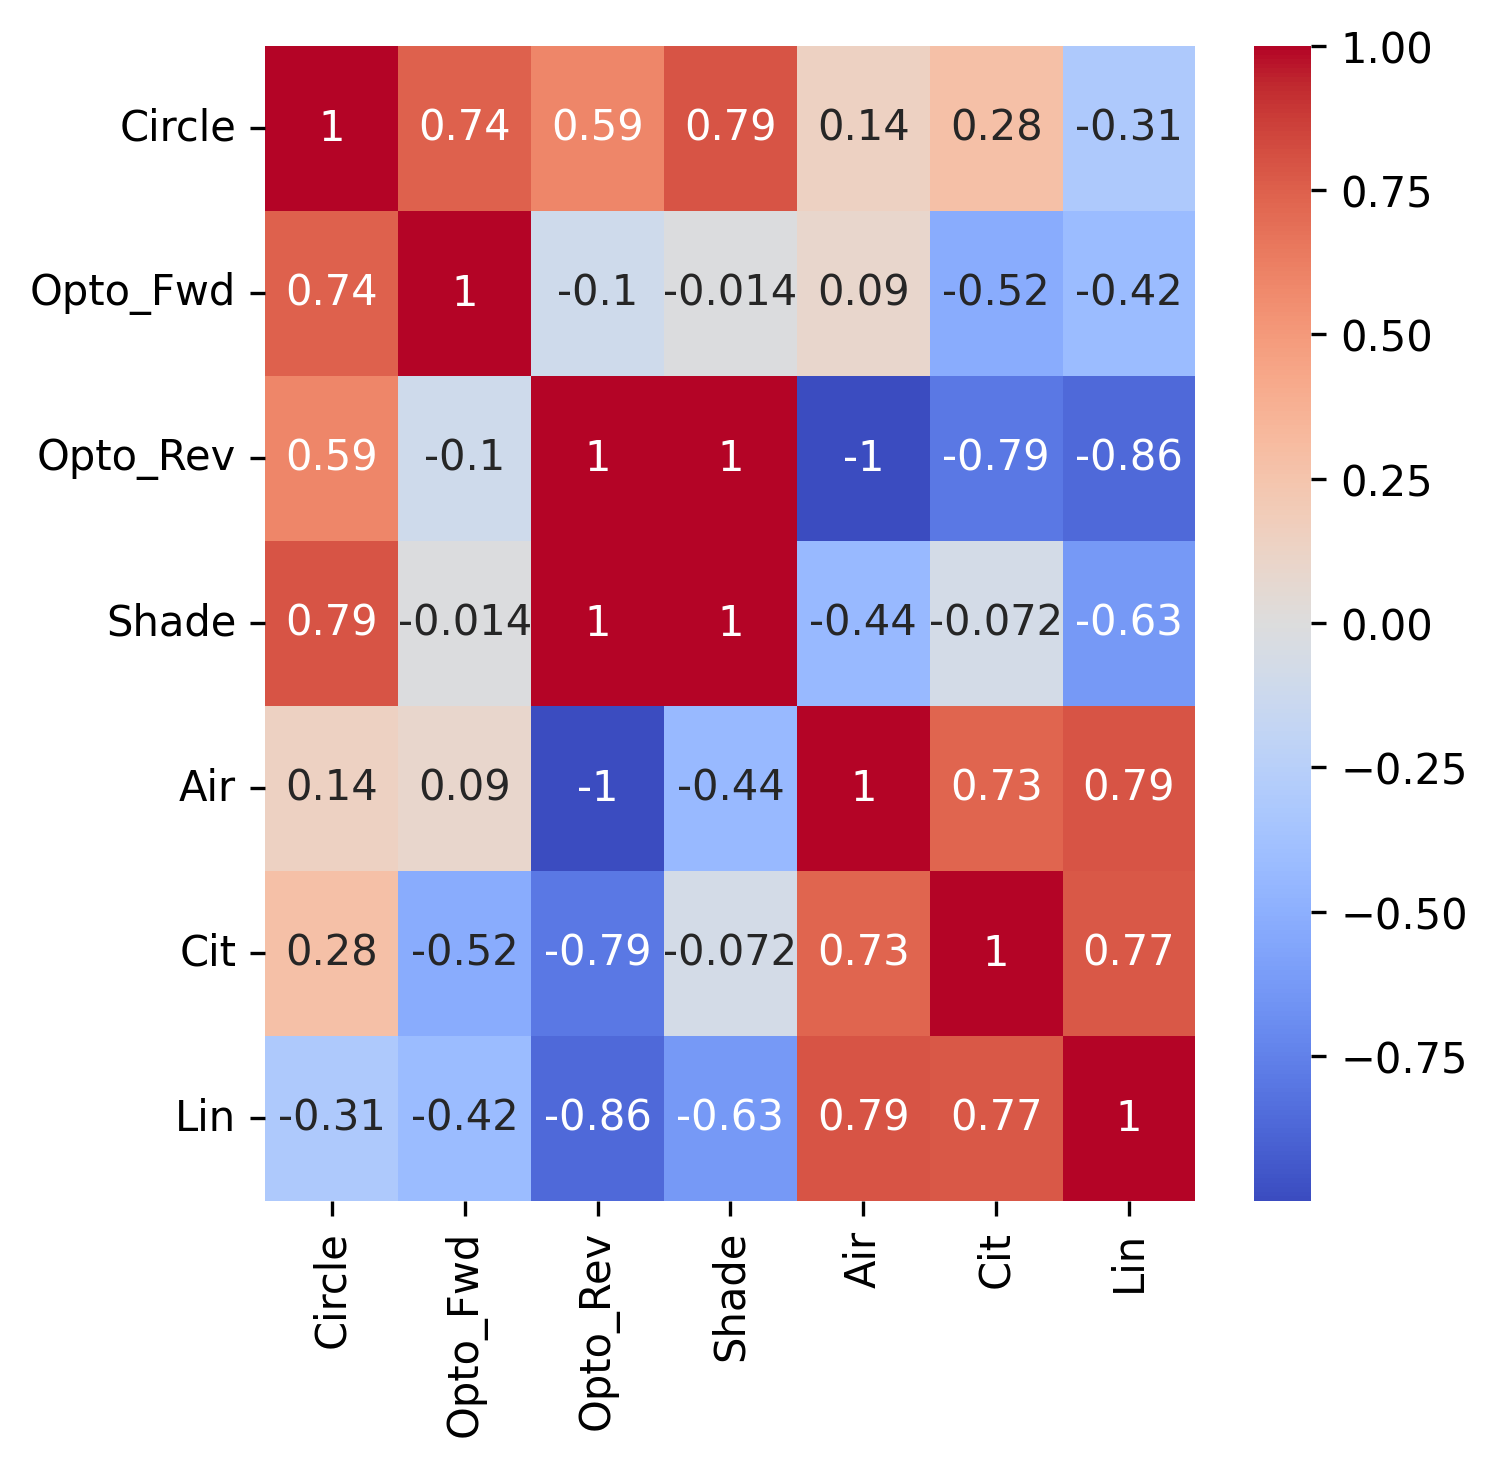

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
df = pd.DataFrame(cMAT)
matrix = df.corr(numeric_only=True)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5),dpi=300)
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.show()
plt.savefig('/content/cmat.pdf',dpi=300)

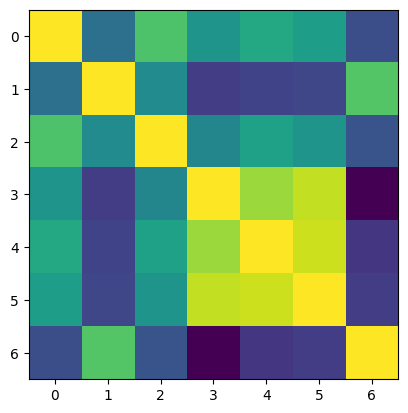

In [ ]:
plt.imshow(matrix)

In [ ]:
mm.shape

(12, 7)

In [38]:
mm = np.zeros((12,7))

for ind,ele in enumerate(cmat):
  mm[ind,:] = ele

ind+=1
for ele in nmat:
  mm[ind,:] = ele
  ind+=1


for ele in range(mm.shape[1]):
  temp = mm[:,ele]
  t1 = (temp-np.nanmean(temp))/np.nanstd(temp)
  mm[:,ele] = t1


In [41]:
np.shape(cmat)

(6, 7)

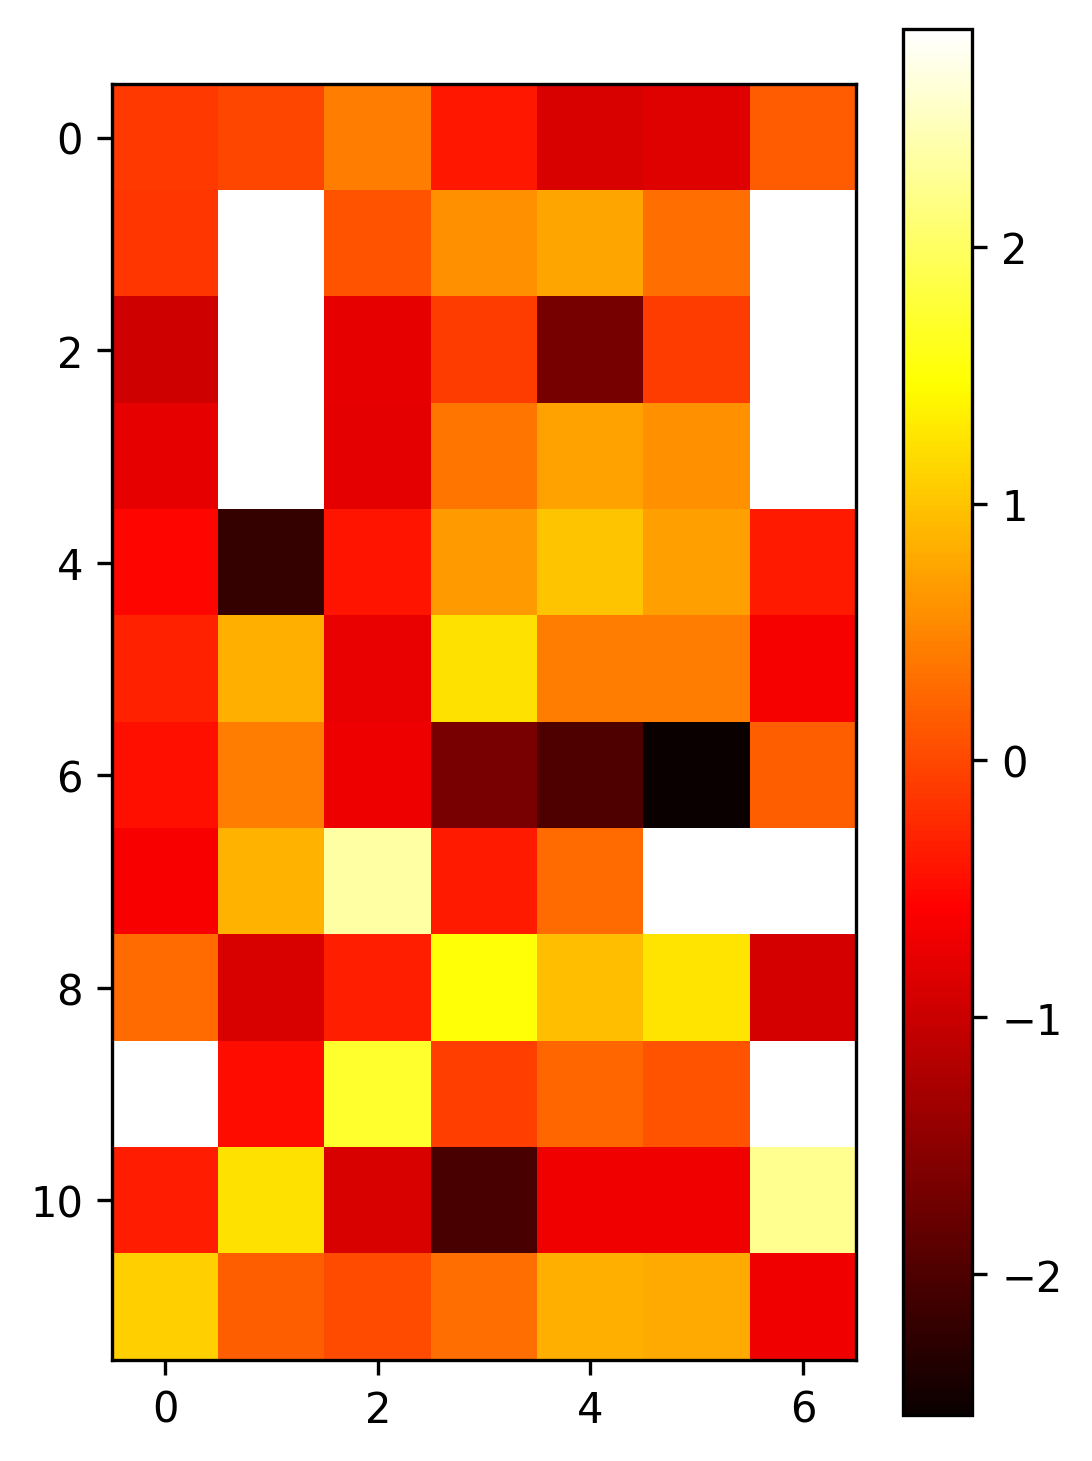

In [ ]:

plt.figure(figsize=(4,6),dpi=300)
plt.imshow(mm,cmap=plt.cm.hot)
plt.colorbar()
plt.grid(False)
plt.savefig('/content/matrix.png',dpi=200)

In [58]:
control_ss = mm[:6,:]
nic_ss = mm[6:,:]

ff_c = []
ff_n = []

for ett in range(0,20):

  tsc = [int(ele) for ele in np.random.rand(6)*6]

  mmtemp_c = []
  for ele in range(0,6):
    temp = control_ss[tsc,ele]
    mmtemp_c.append(np.nanstd(temp))

  tsc = [int(ele) for ele in np.random.rand(6)*6]
  mmtemp_n = []
  for ele in range(0,6):
    temp = nic_ss[tsc,ele]
    mmtemp_n.append(np.nanstd(temp))


  ff_c.append(np.nanmean(mmtemp_c))
  ff_n.append(np.nanmean(mmtemp_n))



control 0.14637503400861093
nicotine 0.9016109578440682


In [63]:
np.nanstd(ff_c)

np.float64(0.1761508982419072)

In [64]:
np.nanstd(ff_n)

np.float64(0.11755310782176721)

Text(0, 0.5, 'Behavioral variation across treatments')

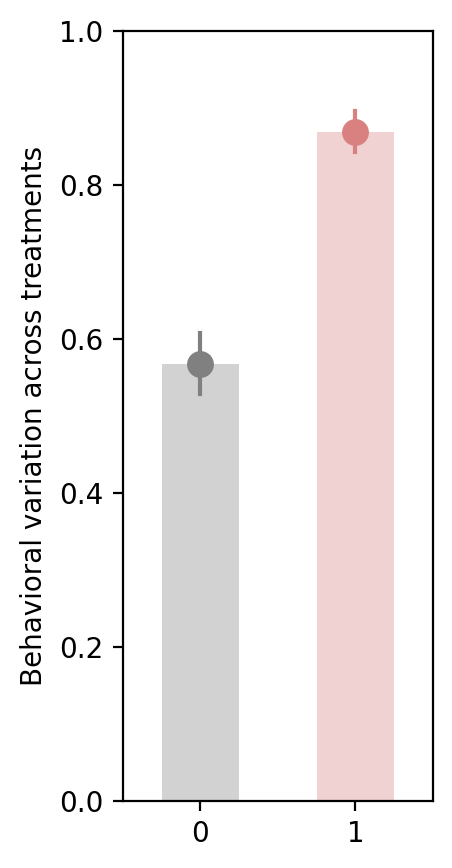

In [98]:
plt.figure(figsize=(2,5),dpi=200)
plt.scatter(0,np.nanmean(ff_c),s=75,color=(0.5,0.5,0.5))
#t = np.zeros(len(ff_c))
#plt.scatter(t,ff_c)
plt.scatter(1,np.nanmean(ff_n),s=75,color=(0.85,0.5,0.5))

plt.plot([0,0],[np.nanmean(ff_c)-(np.nanstd(ff_c)/np.sqrt(len(ff_c))),np.nanmean(ff_c)+(np.nanstd(ff_c)/np.sqrt(len(ff_c)))],color=(0.5,0.5,0.5))
plt.plot([1,1],[np.nanmean(ff_n)-(np.nanstd(ff_n)/np.sqrt(len(ff_n))),np.nanmean(ff_n)+(np.nanstd(ff_n)/np.sqrt(len(ff_n)))],color=(0.85,0.5,0.5))

plt.bar(0,np.nanmean(ff_c),width=0.5,color=(0.5,0.5,0.5,0.35))
plt.bar(1,np.nanmean(ff_n),width=0.5,color=(0.85,0.5,0.5,0.35))


plt.ylim([0,1])
plt.xlim([-0.5,1.5])
plt.ylabel('Behavioral variation across treatments')

In [ ]:
len(cmat[0])

7

In [ ]:
len(nmat)

6

42

In [ ]:
np.nanmean(allStore['nicotine_bee_2']['Circle'])
np.nanmean(allStore['nicotine_bee_2']['Opto_Fwd'])
np.nanmean(allStore['nicotine_bee_2']['Opto_Rev'])
np.nanmean(allStore['nicotine_bee_2']['Shade'])
np.nanmean(allStore['nicotine_bee_2']['Air'])
np.nanmean(allStore['nicotine_bee_2']['Cit'])
np.nanmean(allStore['nicotine_bee_2']['Lin'])

np.float64(254.0289305145478)

In [ ]:
'Opto_Fwd'

In [ ]:
#plt.figure()
crot = []
nrot = []
for ind,ele in enumerate(allStore.keys()):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    crot.append(np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    nrot.append(np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']))

  if 'Opto_Fwd' in allStore[ele] and 'Opto_Rev' in allStore[ele]:


    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Fwd'])-np.nanmean(allStore[ele]['Opto_Fwd']),s=150,color=cc1)
    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']),s=50,color=cc1)
    plt.plot([ind,ind],[np.nanmean(allStore[ele]['Opto_Fwd'])-np.nanmean(allStore[ele]['Opto_Fwd']),np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd'])],color=cc1)


plt.ylabel('Change in Angular Heading Direction')
plt.xticks([])
plt.tight_layout()
plt.savefig('/content/change_opto_ang.png',dpi=300)

# Learning Data

In [ ]:
import pandas as pd

In [ ]:
data_in = pd.read_csv('/content/biol470/final_project/control_bee_1/bee_0408_1_fwd/learninf_cam1_2026-04-08_16-14-47_key.csv')

In [ ]:
data_in.head()

,Unnamed: 0,filepath,x_centroid,y_centroid,x_min,y_min,x_max,y_max,detection_confidence
0,0,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1243.0,537.0,848,213,1638,861,0.817121
1,1,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1270.0,539.5,871,214,1669,865,0.823982
2,2,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1299.5,442.0,916,135,1683,749,0.839956
3,3,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1295.5,454.5,930,143,1661,766,0.829749
4,4,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1347.5,469.0,944,154,1751,784,0.817655


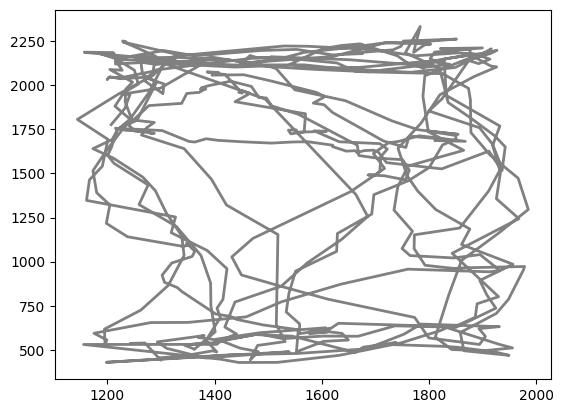

In [ ]:
x_dim = data_in['x_centroid']
y_dim = data_in['y_centroid']

plt.plot(x_dim,y_dim,color=(0.5,0.5,0.5),linewidth=2)

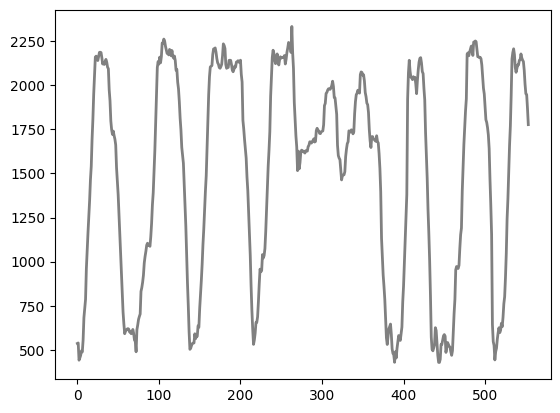

In [ ]:
x_dim = data_in['x_centroid']
y_dim = data_in['y_centroid']

plt.plot(y_dim,color=(0.5,0.5,0.5),linewidth=2)

Text(0, 0.5, 'Count')

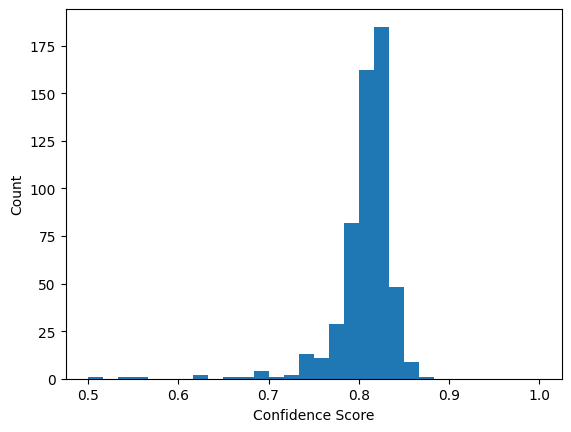

In [ ]:
conf = data_in['detection_confidence'].values
h1 = plt.hist(conf,np.linspace(0.5,1,31))
plt.xlabel('Confidence Score')
plt.ylabel('Count')

In [ ]:
# Confidence thresholding to remove noise from dataset

threshold = 0.8
index = np.array(data_in['detection_confidence'].values) >= 0.8

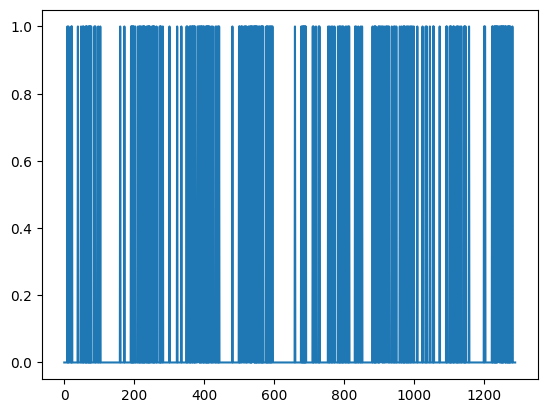

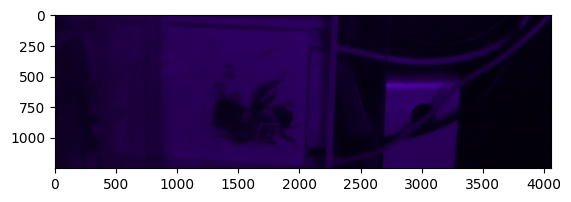

In [ ]:
# Finding the split for green half vs blue half
plt.imshow(frame[1250:2500,:,::-1])

In [ ]:
data_in = pd.read_csv('/content/biol470/final_project/control_bee_1/bee_0408_1_fwd/learninf_cam1_2026-04-08_16-15-57_key.csv')
x_dim = np.array(data_in['x_centroid'])#[index]
y_dim = np.array(data_in['y_centroid'])#[index]

Text(550, 2250, 'Blue')

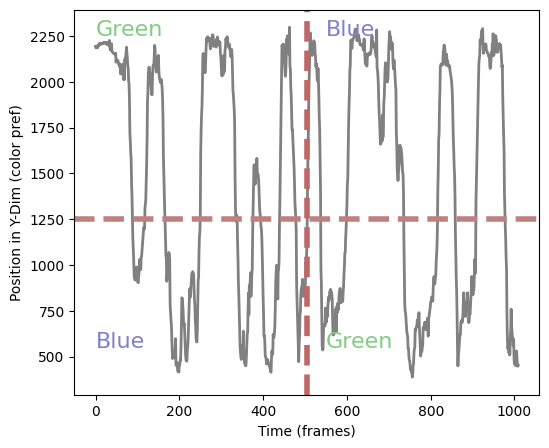

In [ ]:
data_in = pd.read_csv('/content/biol470/final_project/control_bee_1/bee_0408_1_fwd/learninf_cam1_2026-04-08_16-15-57_key.csv')
x_dim = np.array(data_in['x_centroid'])#[index]
y_dim = np.array(data_in['y_centroid'])#[index]

plt.figure(figsize=(6,5))
plt.plot(y_dim,color=(0.5,0.5,0.5),linewidth=2)
a1 = plt.axis()
plt.plot([a1[0],a1[1]],[1250,1250],linestyle='--',linewidth=4,color=(0.75,0.5,0.5))
plt.ylabel('Position in Y-Dim (color pref)')
plt.axis(a1)
#plt.ylim([100,2500])
plt.xlabel('Time (frames)')


ss = len(x_dim)/2
plt.plot([ss,ss],[a1[2],a1[3]],color=(0.75,0.4,0.4),linestyle='--',linewidth=4)
plt.text(0,2250,'Green',color=(0.5,0.8,0.5),fontsize=16)
plt.text(0,550,'Blue',color=(0.5,0.5,0.8),fontsize=16)
plt.text(550,550,'Green',color=(0.5,0.8,0.5),fontsize=16)
plt.text(550,2250,'Blue',color=(0.5,0.5,0.8),fontsize=16)

([], [])

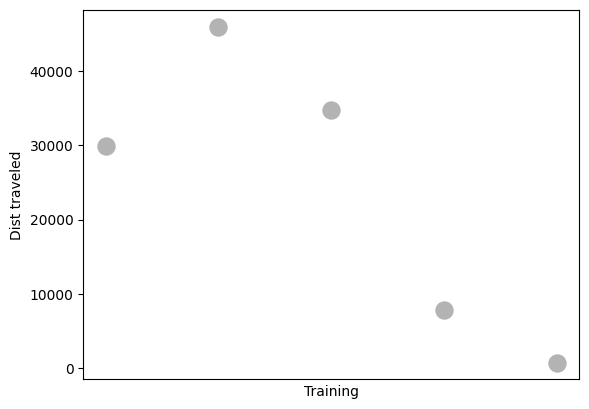

In [ ]:
ffs = glob.glob('/content/biol470/final_project/control_bee_1/bee_0408_1_fwd/*')
ffs.sort()

dist_train = []
for ff1 in ffs:

  data_in = pd.read_csv(ff1)
  y_dim = np.array(data_in['y_centroid'])#[index]
  xy = abs(np.diff(y_dim))
  dist_train.append(np.nansum(xy))

plt.scatter(range(len(dist_train)),dist_train,s=150,color=(0.7,0.7,0.7))
plt.ylabel('Dist traveled')
plt.xlabel('Training')
plt.xticks([])

In [ ]:
# Get exact timing for the eval
# Quant time spent on one side over the other